# Predicting Taxi Trip Duration and Congestion Pricing Exposure in New York City

**Project Checkpoint 2 — Midterm Report**

## Team

| Name | GitHub ID |
|------|-----------|
| Abhishek Mohan Hundalekar | hundalekar — **Point of Contact (POC)** |
| Moses Kamya | mkamya20 |
| Tarun Singh | tsingh15syr |
| Morgan Cook | mcook12e |

## Overview

**What are we trying to do?**  
We are building models that (1) predict how long a yellow taxi trip in NYC will take (in minutes) and (2) predict whether a trip will incur the Central Business District (CBD) congestion fee. The goal is to give drivers and fleet operators a clearer picture of trip duration and when extra charges apply, using only information known at or before trip start.

**What is new in our approach and why might it succeed?**  
We use the **January 2025** NYC TLC trip data, which includes the newly introduced CBD congestion fee. We combine interpretable baselines (linear regression for duration, logistic regression for congestion) with plans for tree-based models (random forest, gradient boosting) to capture non-linear patterns while keeping some results explainable. Our feature set combines time of day, day of week, pickup/dropoff borough, trip distance, and fare-structure ratios, which align with how congestion and duration actually vary.

**Who cares?**  
**Primary stakeholders** are **taxi drivers and fleet operators**: trip duration and congestion fees directly affect earnings and route choices. City transportation agencies and researchers also benefit for policy evaluation. If we are successful, stakeholders get a data-driven view of which trips tend to be longer and when the congestion fee applies, supporting better planning and policy assessment.

## Data

**Source and credibility**  
Our data are the **NYC Yellow Taxi Trip Records for January 2025**, published by the New York City Taxi and Limousine Commission (TLC). The dataset is publicly available, documented with data dictionaries, and comes from mandatory reporting by licensed taxi operators, which supports its credibility.

- **Data source:** [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)  
- We use the January 2025 Parquet file plus the **Taxi Zone Lookup** table to map location IDs to boroughs.

**Validation**  
We confirmed the raw file contains millions of trip records with expected columns (pickup/dropoff datetime, location IDs, trip distance, passenger count, fare components, and the new `cbd_congestion_fee`). We restricted analysis to **January 5–31, 2025** so all trips fall under the post–congestion-pricing period.

**Exploratory analysis — distributions and patterns**  
We explored distributions and relationships across the team. **Distributions:** Trip duration is right-skewed (median ~12 minutes); most trips are short. Trip distance and fare amount are strongly correlated (~0.94), and distance is also highly correlated with duration (~0.80). Single-passenger trips dominate; evening hours (17:00–19:00) have the most pickups. About 15.5% of rows had missing values in a few columns (e.g. passenger_count, RatecodeID), which we addressed in preprocessing.

To **highlight specific patterns**, we include: (1) the distribution of our two targets (trip duration and congestion fee) on the cleaned data; (2) a **correlation heatmap** of key numeric variables to show redundancies and relationships; (3) **trips by hour of day** to show temporal demand; and (4) a **dimensionality reduction** (PCA) on numeric trip features to see whether trips separate by congestion fee in 2D, which can inform feature and model choices.

In [ ]:
%%capture
import pandas as pd
import matplotlib.pyplot as plt

# Load engineered data as it has both targets and cleaned features
df = pd.read_parquet("../data/processed/taxi_engineered.parquet")
# Use a sample for faster plotting
plot_df = df.sample(n=100_000, random_state=42)

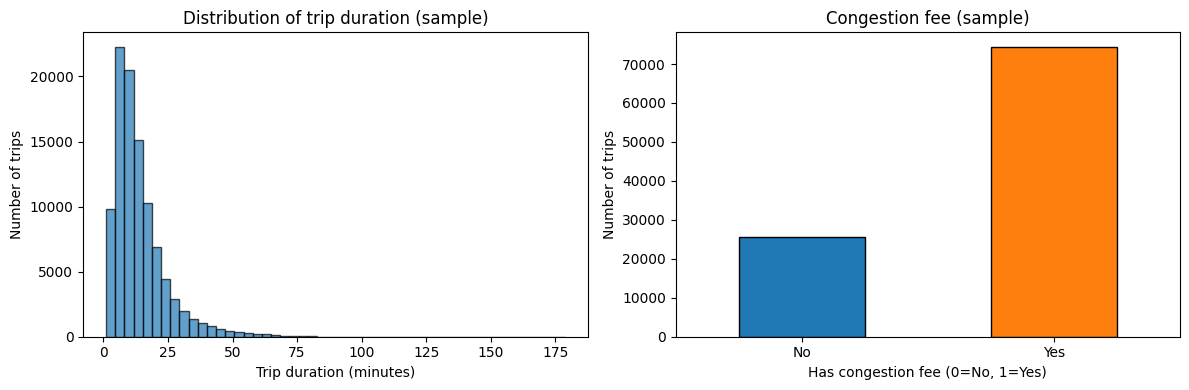

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: distribution of trip duration (minutes)
axes[0].hist(plot_df["trip_duration_min"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Trip duration (minutes)")
axes[0].set_ylabel("Number of trips")
axes[0].set_title("Distribution of trip duration (sample)")

# Right: class balance for congestion fee
plot_df["has_congestion_fee"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["C0", "C1"], edgecolor="black")
axes[1].set_xlabel("Has congestion fee (0=No, 1=Yes)")
axes[1].set_ylabel("Number of trips")
axes[1].set_title("Congestion fee (sample)")
axes[1].set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

**Correlation heatmap**  
The heatmap below shows how strongly key numeric variables are related. Trip distance, fare amount, and trip duration are highly correlated with each other, which suggests we should be mindful of multicollinearity in linear models and that distance is a strong candidate predictor for duration.

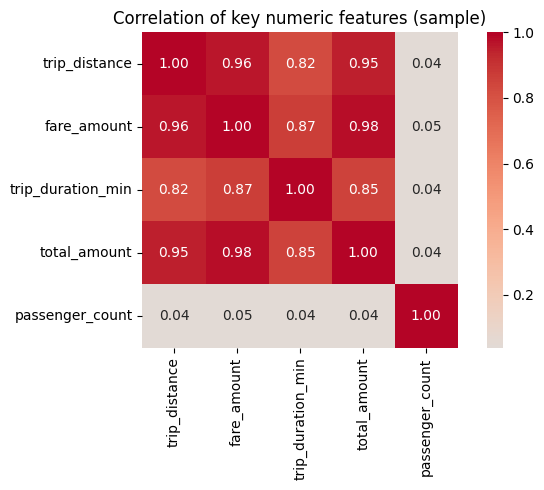

In [5]:
import seaborn as sns

# Key numeric columns for correlation (available in engineered data)
num_cols = ["trip_distance", "fare_amount", "trip_duration_min", "total_amount", "passenger_count"]
sub = plot_df[[c for c in num_cols if c in plot_df.columns]]
corr = sub.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation of key numeric features (sample)")
plt.tight_layout()
plt.show()

**Trips by hour of day**  
Demand is highest during evening rush (around 17:00–19:00). This temporal pattern is useful for both duration and congestion-fee prediction, since time of day is a known-at-pickup feature.

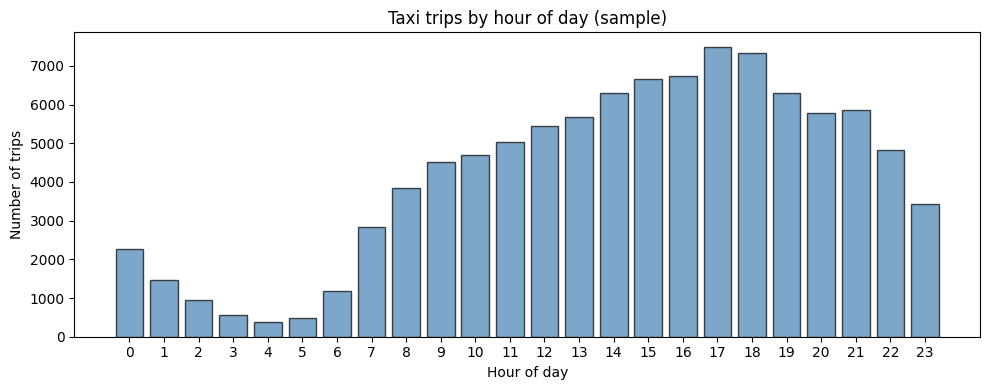

In [6]:
# Trips by hour (engineered data has pickup_hour)
if "pickup_hour" in plot_df.columns:
    by_hour = plot_df["pickup_hour"].value_counts().sort_index()
else:
    by_hour = plot_df["tpep_pickup_datetime"].dt.hour.value_counts().sort_index()
plt.figure(figsize=(10, 4))
plt.bar(by_hour.index, by_hour.values, color="steelblue", alpha=0.7, edgecolor="black")
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.title("Taxi trips by hour of day (sample)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Dimensionality reduction (PCA)**  
We project the numeric trip features  onto the first two principal components and color points by whether the trip had a congestion fee. This helps us see whether the two classes are separable in a low-dimensional view and whether more complex models might capture structure that linear baselines miss.

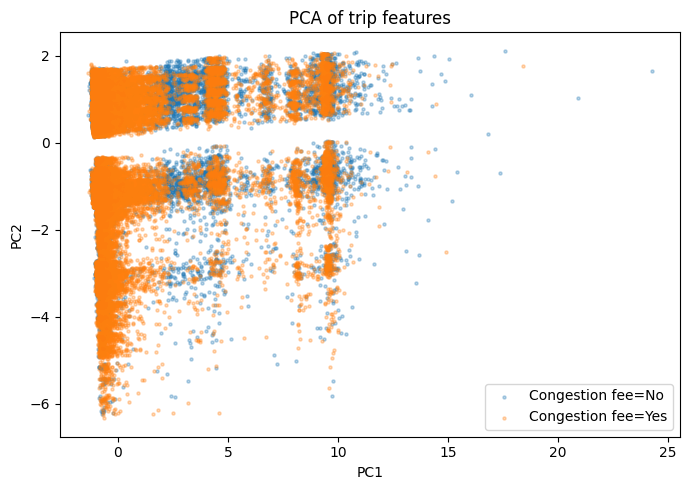

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Numeric features only, no targets or leakage
pca_cols = ["trip_distance", "fare_amount", "passenger_count", "pickup_hour", "pickup_day_of_week",
            "is_weekend", "is_rush_hour", "is_same_borough", "is_airport_pickup", "is_airport_trip",
            "is_single_passenger", "tip_to_total_ratio", "is_extreme_distance", "is_extreme_fare", "store_and_fwd_encoded"]
pca_df = plot_df[[c for c in pca_cols if c in plot_df.columns]].select_dtypes(include=[np.number]).dropna(how="all", axis=1)
if pca_df.shape[1] < 2:
    pca_df = plot_df[["trip_distance", "fare_amount", "passenger_count", "pickup_hour"]].dropna()
X_pca = pca_df.fillna(0)
X_pca = StandardScaler().fit_transform(X_pca)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_pca)
y_plot = plot_df.loc[X_pca.index if hasattr(X_pca, "index") else plot_df.index[: len(X_2d)], "has_congestion_fee"]
if len(y_plot) != len(X_2d):
    y_plot = plot_df["has_congestion_fee"].iloc[: len(X_2d)].values
plt.figure(figsize=(7, 5))
for label in [0, 1]:
    mask = y_plot == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.3, s=5, label=f"Congestion fee={'Yes' if label else 'No'}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of trip features")
plt.legend()
plt.tight_layout()
plt.show()

## Preprocessing

We implemented a cleaning pipeline (in `work/02_data_cleaning/02_data_cleaning.ipynb`) that:

1. **Computed trip duration** from pickup and dropoff timestamps (minutes).
2. **Filtered dates** to January 5–31, 2025 (post–congestion-pricing start).
3. **Dropped invalid durations** (≤ 1 min or > 180 min).
4. **Dropped invalid passenger counts** (0 or > 6).
5. **Dropped invalid RatecodeID** (kept 1–6; removed 99 and missing).
6. **Dropped distance outliers** (≤ 0 or > 100 miles).
7. **Dropped fare outliers** (fare_amount ≤ 0 or > $500; total_amount capped at $600).
8. **Created targets:** `trip_duration_min` (regression) and `has_congestion_fee` (binary: 1 if `cbd_congestion_fee` > 0).

Rows with missing values in key fields were removed as part of the above filters. The result went from ~3.47M raw trips to **~2.45M cleaned trips**. We then built a combined feature-engineering pipeline (temporal, location, trip-derived, and categorical/interaction features) and saved a single dataset for modeling: **45 columns**, stored as `data/processed/taxi_engineered.parquet`. No custom imputation was used; we relied on dropping invalid or out-of-range records.

## Modeling

We ran **two baselines**: one for **congestion-fee classification** and one for **trip duration regression**.

**Congestion-fee (classification)**  
We fit **logistic regression** on features that included trip distance, duration, passenger count, pickup hour, day of week, weekend/rush flags, same-borough and airport flags, and a few derived ratios. Below we reproduce the main evaluation metrics and confusion matrix for this baseline.

**Trip duration (regression)**  
We fit **linear regression** to predict `trip_duration_min` . We use only features known at or before trip start: e.g. trip distance, passenger count, pickup/dropoff borough, time of day, day of week, weekend/rush and airport flags, and encoded categoricals (time_of_day, pickup_borough, dropoff_borough, distance_category, payment_name, ratecode_name). We explicitly drop the target, timestamps, post-trip financials (fare, tip, total_amount, surcharges), and `avg_speed_mph` (which depends on duration). Features are standardized with `StandardScaler`, categoricals are label-encoded, and we use an 80/20 train/test split. We report RMSE, MAE, R², compare to a naive baseline (predicting the training mean).

In [13]:
%%capture
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

data = pd.read_parquet("../data/processed/taxi_engineered.parquet").sample(n=100_000, random_state=42)
drop_cols = ["has_congestion_fee", "congestion_surcharge", "cbd_congestion_fee", "cbd_fee_ratio",
    "tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID", "hour_x_dayofweek", "time_slot",
    "payment_name", "ratecode_name", "pickup_borough", "dropoff_borough", "distance_category",
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
    "total_amount", "Airport_fee", "total_surcharges", "surcharges_ratio", "base_fare_ratio"]
existing = [c for c in drop_cols if c in data.columns]
X = data.drop(columns=existing).select_dtypes(include=[np.number])
y = data["has_congestion_fee"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_probs = model.predict_proba(X_test_s)[:, 1]

Baseline: Logistic regression — Has congestion fee (100k sample)
Accuracy: 0.7587
AUC: 0.6949
Confusion matrix (rows=true, cols=predicted):
[[  613  4505]
 [  322 14560]]


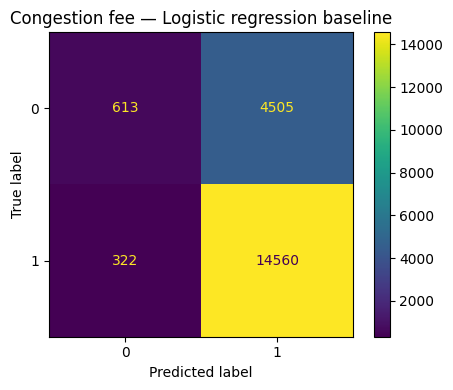

In [15]:
print("Baseline: Logistic regression — Has congestion fee (100k sample)")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_probs), 4))
print("Confusion matrix (rows=true, cols=predicted):")
print(confusion_matrix(y_test, y_pred))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.title("Congestion fee — Logistic regression baseline")
plt.tight_layout()
plt.show()

### Trip duration baseline — Linear Regression

In [ ]:
%%capture
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

data_dur = pd.read_parquet("../data/processed/taxi_engineered.parquet").sample(n=100_000, random_state=42)
target = "trip_duration_min"
y_dur = data_dur[target]

drop_cols_dur = [
    "trip_duration_min", "has_congestion_fee", "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
    "total_amount", "Airport_fee", "congestion_surcharge", "cbd_congestion_fee",
    "avg_speed_mph", "tip_to_total_ratio", "is_extreme_fare", "cbd_fee_ratio",
    "total_surcharges", "surcharges_ratio", "base_fare_ratio",
    "store_and_fwd_encoded", "VendorID", "payment_type",
]
existing_drops = [c for c in drop_cols_dur if c in data_dur.columns]
X_dur = data_dur.drop(columns=existing_drops)

# Encode categoricals 
cat_cols = X_dur.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    if X_dur[col].dtype.name == "category":
        X_dur[col] = X_dur[col].astype(str)
    X_dur[col] = X_dur[col].fillna("Unknown")
    X_dur[col] = LabelEncoder().fit_transform(X_dur[col].astype(str))

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dur, y_dur, test_size=0.2, random_state=42
)
scaler_d = StandardScaler()
X_train_d = scaler_d.fit_transform(X_train_d)
X_test_d = scaler_d.transform(X_test_d)
model_dur = LinearRegression()
model_dur.fit(X_train_d, y_train_d)
y_pred_train_d = model_dur.predict(X_train_d)
y_pred_test_d = model_dur.predict(X_test_d)

In [17]:
# Duration baseline — evaluation (RMSE, MAE, R², naive baseline, stakeholder goal)
train_rmse = np.sqrt(mean_squared_error(y_train_d, y_pred_train_d))
test_rmse = np.sqrt(mean_squared_error(y_test_d, y_pred_test_d))
train_mae = mean_absolute_error(y_train_d, y_pred_train_d)
test_mae = mean_absolute_error(y_test_d, y_pred_test_d)
train_r2 = r2_score(y_train_d, y_pred_train_d)
test_r2 = r2_score(y_test_d, y_pred_test_d)
naive_pred = np.full_like(y_test_d, y_train_d.mean())
naive_rmse = np.sqrt(mean_squared_error(y_test_d, naive_pred))
improvement_pct = ((naive_rmse - test_rmse) / naive_rmse) * 100

print("=" * 50)
print("TRIP DURATION BASELINE — Linear Regression")
print("=" * 50)
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'RMSE (min)':<20} {train_rmse:>10.2f} {test_rmse:>10.2f}")
print(f"{'MAE (min)':<20} {train_mae:>10.2f} {test_mae:>10.2f}")
print(f"{'R²':<20} {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"\nNaive baseline RMSE: {naive_rmse:.2f} min — model is {improvement_pct:.1f}% better (RMSE)")
print(f"Stakeholder goal (RMSE < 10 min): {'✅ ACHIEVED' if test_rmse < 10 else '❌ Not yet'} — Test RMSE = {test_rmse:.2f} min")
print(f"Overfitting check: Train–Test RMSE gap = {abs(train_rmse - test_rmse):.2f} min")

TRIP DURATION BASELINE — Linear Regression
Metric                    Train       Test
------------------------------------------
RMSE (min)                 5.41       5.45
MAE (min)                  3.74       3.74
R²                       0.7420     0.7365

Naive baseline RMSE: 10.62 min — model is 48.7% better (RMSE)
Stakeholder goal (RMSE < 10 min): ✅ ACHIEVED — Test RMSE = 5.45 min
Overfitting check: Train–Test RMSE gap = 0.04 min


**Diagnostic plots (trip duration baseline)**  
The three plots below help us check whether the linear regression model is behaving well:

1. **Actual vs Predicted** — Each point is a test trip. Points near the red dashed line (perfect prediction) are good; scattered points around the line with no strong curve suggest the model is capturing the relationship reasonably. The reported R² and RMSE summarize fit quality.
2. **Residual distribution** — Residuals are “actual duration minus predicted duration.” For a well-behaved model we expect them to be roughly centered at zero and somewhat symmetric. The blue line shows the mean residual; we want it close to zero.
3. **Residuals vs Predicted** — We want a random-looking cloud around zero. If there were a clear curve or funnel shape, that would suggest the model is missing some structure (e.g. under-predicting long trips).

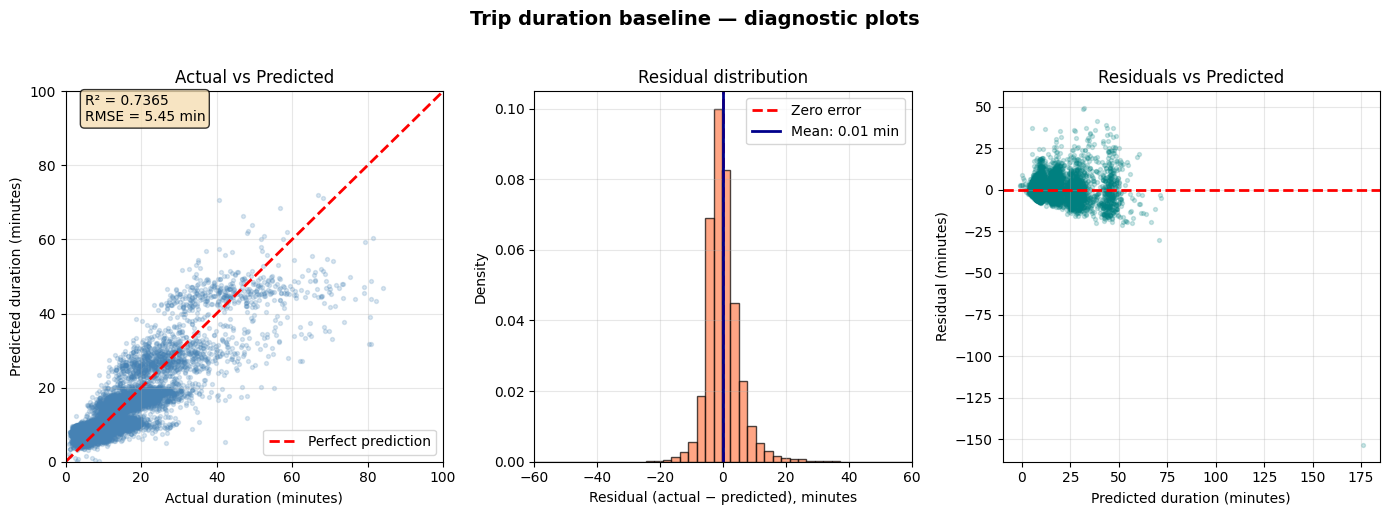

In [18]:
# Diagnostic plots for duration baseline (from Abhishek_Baseline.ipynb)
residuals_d = np.array(y_test_d) - y_pred_test_d
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Trip duration baseline — diagnostic plots", fontsize=14, fontweight="bold", y=1.02)

n_plot = min(10_000, len(y_test_d))
idx = np.random.RandomState(42).choice(len(y_test_d), size=n_plot, replace=False)
y_test_arr = np.array(y_test_d)

# 1. Actual vs Predicted
axes[0].scatter(y_test_arr[idx], y_pred_test_d[idx], alpha=0.2, s=8, color="steelblue")
max_val = max(y_test_arr.max(), y_pred_test_d.max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual duration (minutes)")
axes[0].set_ylabel("Predicted duration (minutes)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].text(0.05, 0.92, f"R² = {test_r2:.4f}\nRMSE = {test_rmse:.2f} min", transform=axes[0].transAxes, fontsize=10, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# 2. Residual distribution
axes[1].hist(residuals_d, bins=80, color="coral", edgecolor="black", alpha=0.7, density=True)
axes[1].axvline(0, color="red", linewidth=2, linestyle="--", label="Zero error")
axes[1].axvline(np.mean(residuals_d), color="darkblue", linewidth=2, linestyle="-", label=f"Mean: {np.mean(residuals_d):.2f} min")
axes[1].set_xlabel("Residual (actual − predicted), minutes")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(-60, 60)

# 3. Residuals vs Predicted
axes[2].scatter(y_pred_test_d[idx], residuals_d[idx], alpha=0.2, s=8, color="teal")
axes[2].axhline(0, color="red", linewidth=2, linestyle="--")
axes[2].set_xlabel("Predicted duration (minutes)")
axes[2].set_ylabel("Residual (minutes)")
axes[2].set_title("Residuals vs Predicted")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Feature importance (trip duration)**  
Because we scaled features with `StandardScaler`, the linear regression coefficients are comparable: **larger absolute value means the feature has a stronger effect on predicted duration.** Red bars = positive coefficient (higher feature value → longer predicted trip); blue bars = negative (higher value → shorter predicted trip). This tells us which inputs the model relies on most (e.g. trip distance, borough, time of day) and supports stakeholder-facing explanations.

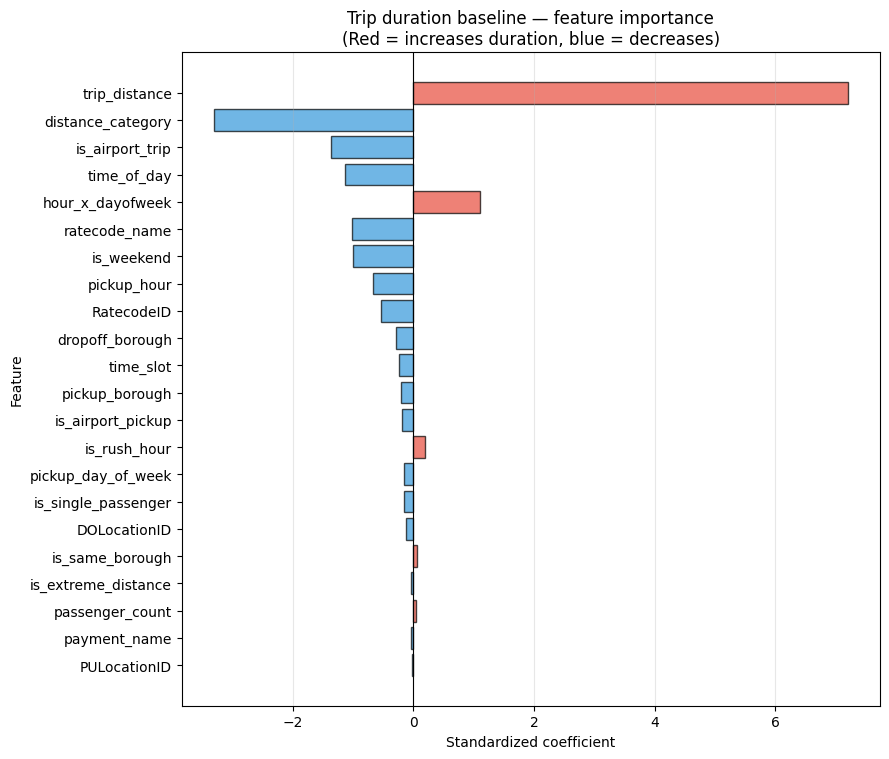

In [ ]:
# Feature importance: standardized coefficients 
feature_names_d = X_dur.columns.tolist()
coef_df = pd.DataFrame({"Feature": feature_names_d, "Coefficient": model_dur.coef_})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(9, max(5, len(feature_names_d) * 0.35)))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="black", alpha=0.7)
ax.set_xlabel("Standardized coefficient")
ax.set_ylabel("Feature")
ax.set_title("Trip duration baseline — feature importance\n(Red = increases duration, blue = decreases)")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Problems & Challenges

- **Missing data:** 15.5% of rows had missing values in passenger_count, RatecodeID, store_and_fwd_flag, and some surcharge columns. We chose to drop these rows rather than impute, to keep the pipeline simple and avoid introducing bias; we may revisit imputation or a “missing” indicator in a later phase.
- **Class imbalance:** Congestion fee is present for about 74% of cleaned trips, so the “no fee” class is a minority. The baseline logistic regression still achieves reasonable accuracy and AUC; we will consider class weights or resampling when we move to tree-based models.
- **Feature leakage:** We had to carefully exclude variables derived from the target (e.g. `avg_speed_mph` for duration, `cbd_congestion_fee` for congestion prediction) and document this in the feature-engineering notebook so the modeling notebook uses a clean set of features.
- **Scale and runtime:** The full dataset has 2.45M rows. For quick iteration we used a 100k sample for the baseline, we plan to run full-data or larger-sample baselines and cross-validation in the next phase.

## Next steps

- **Encoding and full pipeline:** In a dedicated modeling notebook, add proper encoding for categoricals (e.g. OneHotEncoder or target encoding) and run both duration and congestion baselines on a larger sample or full data with a proper train/validation/test .
- **Advanced models:** Train random forest and gradient boosting (e.g. XGBoost or LightGBM) for both tasks; compare with baselines and report feature importance. 
- **Documentation and deliverables:** Finalize a short report or slides summarizing objectives, data, preprocessing, model results, and stakeholder takeaways. 